In [ ]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.integrate import quad


import xobjects as xo
import xtrack as xt
import xpart as xp
import xcoll as xc

import pandas as pd

# Make a context and get a buffer
context = xo.ContextCpu()         # For CPU
# context = xo.ContextCupy()      # For CUDA GPUs
# context = xo.ContextPyopencl()  # For OpenCL GPUs

In [ ]:
# initialize the particles
num_part = int(10000)
x_init = 0.002 * np.ones(num_part)
px_init = np.zeros(num_part)
y_init   = np.zeros(num_part)
py_init  = np.zeros(num_part)

def initialize_particles(context, num_particles=num_part):
    return xp.Particles(
        _context=context,
        x=x_init,  # Replace with actual particle positions
        px=px_init,  # Replace with actual momenta
        y=y_init,
        py=py_init,
        delta=0,
        p0c=4e11
    )
    

In [3]:
# Define the crystal properties (initial values)
length = 0.002
material = xc.materials.SiliconCrystal
width = 0.002
height = 0.05
side = '+'
miscut = 0.0
lattice = 'strip'
jaw = 0.001

In [4]:
# Dataframe to store particle tracking information
columns = ['iteration', 'particle_id', 'x', 'px']
tracking_data = pd.DataFrame(columns=columns)

In [5]:
min_angle = 10
max_angle = 500
steps = 10
# Define the range of bending angles to iterate over
bending_angles = [i * 1e-6 for i in range(min_angle, max_angle, steps)]  # Example: 100 µrad to 200 µrad in 10 µrad steps


In [6]:
# List to collect all tracking data
tracking_data_list = []

# Loop over bending angles
for iteration, bendin_angle in enumerate(bending_angles):
    # Create the crystal with the current bending angle
    coll = xc.EverestCrystal(
        length=length,
        material=material,
        bending_angle=bendin_angle,
        width=width,
        height=height,
        side=side,
        miscut=miscut,
        lattice=lattice,
        jaw=jaw,
        _context=context
    )
    
    # Initialize a new beam of particles for this iteration
    part = initialize_particles(context)
    
    # Track particles through the crystal
    coll.track(part)  # Updates the particle states in place
    
    # Collect particle data for this iteration
    for i in range(len(part.x)):
        tracking_data_list.append({
            'iteration': iteration,
            'particle_id': i,
            'x': part.x[i],
            'px': part.px[i],
        })

# Convert the collected data into a DataFrame
tracking_data = pd.DataFrame(tracking_data_list)


In [7]:
# Perform analysis or save the DataFrame
print(tracking_data.head())


   iteration  particle_id      x        px
0          0            0  0.002  0.000007
1          0            1  0.002  0.000008
2          0            2  0.002  0.000017
3          0            3  0.002  0.000004
4          0            4  0.002  0.000006


In [8]:
# Define Gaussian function for fitting
def gaussian(x, amp, mean, sigma):
    return amp * np.exp(-((x - mean)**2) / (2 * sigma**2))

# Placeholder for efficiencies
efficiencies = []

# Loop over iterations
for iteration in tracking_data['iteration'].unique():
    # Filter data for the current iteration
    iteration_data = tracking_data[tracking_data['iteration'] == iteration]
    px_values = iteration_data['px']
    
    # Generate the histogram data for plotting and fitting
    counts, bin_edges = np.histogram(px_values, bins=2000, density=False)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    bin_width = bin_edges[1] - bin_edges[0]
    
    # Create histogram
    hist, bin_edges = np.histogram(px_values, bins=np.arange(min(px_values), max(px_values) + bin_width, bin_width))
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    # Initial guesses for Gaussian parameters (amplitude, mean, stddev)
    initial_guess = [max(hist), np.mean(px_values), np.std(px_values)]
    
    # Fit the histogram with the Gaussian
    try:
        popt, _ = curve_fit(gaussian, bin_centers, hist, p0=initial_guess)
    except RuntimeError:
        print(f"Gaussian fit failed for iteration {iteration}")
        efficiencies.append(None)
        continue

    # Calculate efficiency
    amplitude, mean, stddev = popt
    integral_of_fit = amplitude * stddev * np.sqrt(2 * np.pi)  # Integral of the Gaussian
    efficiency = abs(integral_of_fit / (num_part * bin_width))
    efficiencies.append(efficiency)

bendin_angle = min_angle + tracking_data['iteration'].unique() * steps   
# Save efficiencies to DataFrame for analysis
efficiency_data = pd.DataFrame({
    'Crystal bending angle (muRad)': bendin_angle,
    'efficiency': efficiencies
})

# Display the efficiency data
print(efficiency_data)

    Crystal bending angle (muRad)  efficiency
0                              10    0.933424
1                              20    0.887064
2                              30    0.886698
3                              40    0.873159
4                              50    0.862774
5                              60    0.861851
6                              70    0.859426
7                              80    0.853484
8                              90    0.851513
9                             100    0.850165
10                            110    0.839423
11                            120    0.833193
12                            130    0.832951
13                            140    0.828323
14                            150    0.815473
15                            160    0.808963
16                            170    0.811927
17                            180    0.801399
18                            190    0.803740
19                            200    0.792403
20                            210 

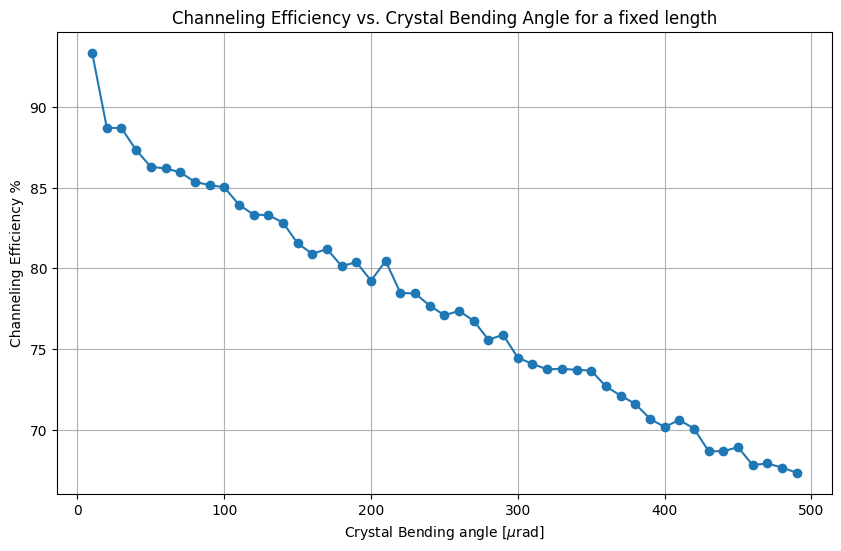

In [9]:
# Ensure efficiencies and bending angles are in the same order
efficiency_data['bending_angle'] = [bendin_angle for bendin_angle in bending_angles]  # Assuming `bending_angles` was defined earlier

# Plot Channeling Efficiency vs Bending Angle
plt.figure(figsize=(10, 6))
plt.plot(efficiency_data['bending_angle']*10e5, efficiency_data['efficiency'] * 100, marker='o', linestyle='-')

# Customize the plot
plt.title('Channeling Efficiency vs. Crystal Bending Angle for a fixed length')
plt.xlabel(r'Crystal Bending angle [$\mu$rad]')
plt.ylabel('Channeling Efficiency %')
plt.grid(True)
plt.show()